Loading Library

In [2]:
import pandas as pd
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt

c:\Users\hp\.conda\envs\mlenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Loading KPI Dataset

In [4]:
df = pd.read_csv("KPI_Forecasting_Sample_KPI_report _30_months.csv")

print("Sample KPI file loaded successfully")
print("Rows:", len(df))
print("Columns:", df.columns.tolist())

df.head()

Sample KPI file loaded successfully
Rows: 3000
Columns: ['Unnamed: 0', 'Date', 'Cluster', 'Cell', 'Traffic_GB']


,Unnamed: 0,Date,Cluster,Cell,Traffic_GB
0,0,31-01-2023,Cluster_1,Cluster_1_Cell_1,170.7
1,1,28-02-2023,Cluster_1,Cluster_1_Cell_1,174.2
2,2,31-03-2023,Cluster_1,Cluster_1_Cell_1,190.9
3,3,30-04-2023,Cluster_1,Cluster_1_Cell_1,214.1
4,4,31-05-2023,Cluster_1,Cluster_1_Cell_1,231.3


Converting Data Coulamn

In [5]:
df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True,
    errors="coerce"
)

df = df.dropna(subset=["Date"])

print("After fixing dates:", len(df))

After fixing dates: 3000


Remove Duplicate cell and records

In [6]:
df = df.sort_values(["Cell", "Date"])
df = df.drop_duplicates(subset=["Cell", "Date"], keep="first")

print("After duplicate Cell-Date removal:", len(df))

After duplicate Cell-Date removal: 3000


Removing Missing Value

In [7]:
df = df.dropna(subset=["Date", "Cell", "Traffic_GB"])

print("After removing missing values:", len(df))

After removing missing values: 3000


Validating KPI Value

In [8]:
df = df[df["Traffic_GB"] > 0]

print("After removing non-positive traffic values:", len(df))

After removing non-positive traffic values: 3000


Sort Time series data

In [9]:
df = df.sort_values(["Cell", "Date"])

Data Quality Summer

In [10]:
print("\nFINAL DATA QUALITY SUMMARY")
print("----------------------------")

print("Total rows after validation:", len(df))
print("Number of unique cells:", df["Cell"].nunique())
print("Date range:", df["Date"].min(), "to", df["Date"].max())

df.describe()


FINAL DATA QUALITY SUMMARY
----------------------------
Total rows after validation: 3000
Number of unique cells: 100
Date range: 2023-01-31 00:00:00 to 2025-06-30 00:00:00


,Unnamed: 0,Date,Traffic_GB
count,3000.000000,3000,3000.000000
mean,1499.500000,2024-04-15 03:59:59.999999744,1984.717100
min,0.000000,2023-01-31 00:00:00,132.800000
25%,749.750000,2023-08-31 00:00:00,530.325000
50%,1499.500000,2024-04-15 00:00:00,1232.000000
75%,2249.250000,2024-11-30 00:00:00,2912.725000
max,2999.000000,2025-06-30 00:00:00,14042.700000
std,866.169729,NaN,1916.916847


Savw amd Validate dataset

In [11]:
validated_file = "Validated_KPI_Report_30_Months.csv"

df.to_csv(validated_file, index=False)

print(f"\nValidated KPI file saved as: {validated_file}")


Validated KPI file saved as: Validated_KPI_Report_30_Months.csv


Relode validated dataset

In [12]:
df = pd.read_csv(validated_file)

df["Date"] = pd.to_datetime(df["Date"])

print("Validated KPI file reloaded for AI training.")
print("Rows available for modeling:", len(df))

Validated KPI file reloaded for AI training.
Rows available for modeling: 3000


Initialise forcaating value

In [13]:
future_months = 6

forecast_rows = []

Traingin Prophet model for cell

In [14]:
for cell, cell_df in df.groupby("Cell"):

    prophet_df = cell_df.rename(
        columns={"Date": "ds", "Traffic_GB": "y"}
    )[["ds", "y"]]

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False
    )

    model.fit(prophet_df)

    future = model.make_future_dataframe(
        periods=future_months,
        freq="ME"
    )

    forecast = model.predict(future)

    future_forecast = forecast.tail(future_months)

    for _, row in future_forecast.iterrows():
        forecast_rows.append({
            "Date": row["ds"],
            "Cell": cell,
            "Forecast_Traffic_GB": round(row["yhat"], 1)
        })

15:46:34 - cmdstanpy - INFO - Chain [1] start processing
15:46:34 - cmdstanpy - INFO - Chain [1] done processing
15:46:34 - cmdstanpy - INFO - Chain [1] start processing
15:46:46 - cmdstanpy - INFO - Chain [1] done processing
15:46:46 - cmdstanpy - INFO - Chain [1] start processing
15:46:46 - cmdstanpy - INFO - Chain [1] done processing
15:46:46 - cmdstanpy - INFO - Chain [1] start processing
15:46:46 - cmdstanpy - INFO - Chain [1] done processing
15:46:46 - cmdstanpy - INFO - Chain [1] start processing
15:46:46 - cmdstanpy - INFO - Chain [1] done processing
15:46:47 - cmdstanpy - INFO - Chain [1] start processing
15:46:47 - cmdstanpy - INFO - Chain [1] done processing
15:46:47 - cmdstanpy - INFO - Chain [1] start processing
15:46:47 - cmdstanpy - INFO - Chain [1] done processing
15:46:47 - cmdstanpy - INFO - Chain [1] start processing
15:46:47 - cmdstanpy - INFO - Chain [1] done processing
15:46:47 - cmdstanpy - INFO - Chain [1] start processing
15:46:47 - cmdstanpy - INFO - Chain [1]

Build forecast KPI Report

In [15]:
forecast_df = pd.DataFrame(forecast_rows)

forecast_df.head(10)

,Date,Cell,Forecast_Traffic_GB
0,2025-07-31,Cluster_1_Cell_1,3102.4
1,2025-08-31,Cluster_1_Cell_1,3178.8
2,2025-09-30,Cluster_1_Cell_1,3289.1
3,2025-10-31,Cluster_1_Cell_1,3407.6
4,2025-11-30,Cluster_1_Cell_1,3564.8
5,2025-12-31,Cluster_1_Cell_1,3746.7
6,2025-07-31,Cluster_1_Cell_10,5381.7
7,2025-08-31,Cluster_1_Cell_10,5868.3
8,2025-09-30,Cluster_1_Cell_10,6175.2
9,2025-10-31,Cluster_1_Cell_10,6594.6


FOrecast Validated Plot

15:48:14 - cmdstanpy - INFO - Chain [1] start processing
15:48:14 - cmdstanpy - INFO - Chain [1] done processing


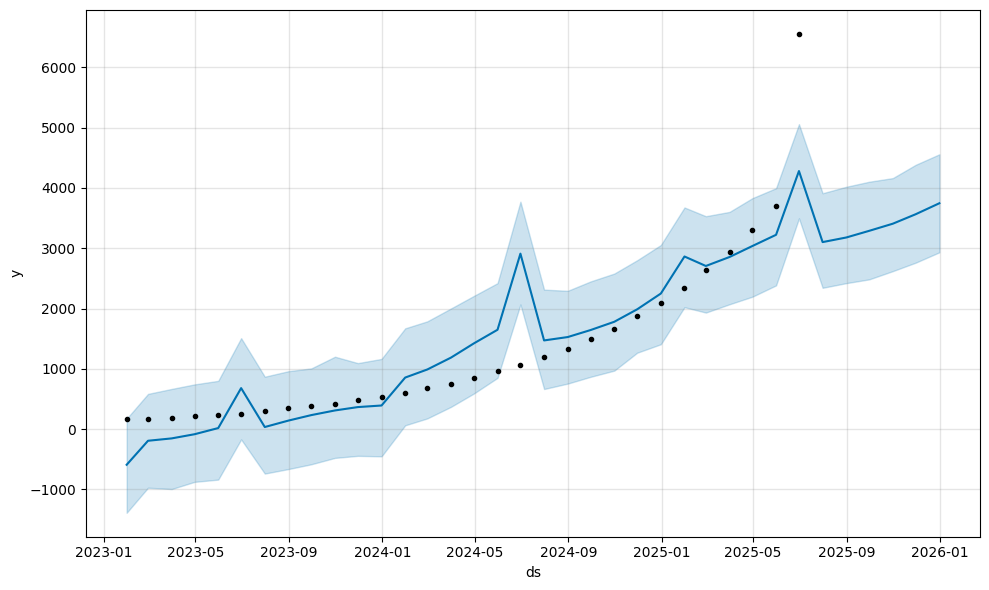

In [16]:
sample_cell = df["Cell"].iloc[0]

cell_df = df[df["Cell"] == sample_cell].rename(
    columns={"Date": "ds", "Traffic_GB": "y"}
)

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(cell_df)

future = model.make_future_dataframe(periods=6, freq="ME")

forecast = model.predict(future)

model.plot(forecast)

plt.show()

Save    Forecaste ouutput


In [17]:
forecast_df.to_csv(
    "Traffic_Forecast_Next_6_Months_Per_Cell_Prophet.csv",
    index=False
)

print("Forecast KPI report saved successfully")

Forecast KPI report saved successfully
